In [ ]:
%pip install numpy matplotlib 

# Generator testovacích dat

pro vygenerovaní testovacích dat / souboru použijte funkci níže a nahraďte novým nazvem souboru tak aby nebyl shodný s již vygenerovaným

In [ ]:
from funkce import generator_nahodnych_dat
    
generator_nahodnych_dat.GeneratorDat().generuj_soubor("firma_derava_stabilni.csv", "stabilni")
generator_nahodnych_dat.GeneratorDat().generuj_soubor("firma_derava_rostouci.csv", "rostouci")

# Načítaní dat ze složky DATA

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from funkce import vypocty
from funkce import nacitanisouboru
from funkce import predikce_prijmu_a_vydaju
from funkce import soucet_jednotlivych_mesicu

# Načítáme data z CSV souborů v adresáři "DATA"
slozka_s_daty = "DATA"
vsechna_data = nacitanisouboru.NacitaniDat().nacti(slozka_s_daty)




# Řešení pomocí linearní regrese 

Zde je řešení pomocí linearni regrese a součtu jednotlivých měsíců 
Motivace proč to takhle řešit: 
1. Linearni regrese býva přímočará a kolikrat velice elegantí
2. Když sečteme všechny častky za měsíc tak mužeme docílit mála dat které se jednoduše spojí a můžeme tak odhadnout chování funkce
3. U daní se hodí to sčítat již na zakladě vzorce pro vypočet zakladní daně:

Zaklad daně = $\sum přijmy - \sum výdaje$

In [ ]:
sumy_za_mesice = soucet_jednotlivych_mesicu.soucet().secti_mesicni_transakce(vsechna_data)

print(f"Načteno {len(vsechna_data)} souborů CSV z adresáře '{slozka_s_daty}'.")
dane_jednotlive_mesice = {}
prijmy_predikce = {}
vydaje_predikce = {}
predikovane_dane = {}
nazvy_firem = []
for nazvy_firmy, data_firmy in sumy_za_mesice.items():
    print(data_firmy)
    dan = vypocty.Vypocty().aktualni_dane(data_firmy["prijmy"], data_firmy["vydaje"])
    dane_jednotlive_mesice[nazvy_firmy] = dan
    prijmy_predikce[nazvy_firmy] = predikce_prijmu_a_vydaju.Predikce().predikuj_pole(data_firmy["prijmy"])
    vydaje_predikce[nazvy_firmy] = predikce_prijmu_a_vydaju.Predikce().predikuj_pole(data_firmy["vydaje"])
    predikovane_dane[nazvy_firmy] = vypocty.Vypocty().aktualni_dane(prijmy_predikce[nazvy_firmy], vydaje_predikce[nazvy_firmy])
    nazvy_firem.append(nazvy_firmy)

print(dane_jednotlive_mesice)



# Predikované data 

In [ ]:

for firma in nazvy_firem:
    plt.figure(figsize=(10, 5))
    plt.plot(prijmy_predikce[firma], label='Předpověď příjmů', marker='o')
    plt.plot(vydaje_predikce[firma], label='Předpověď výdajů', marker='o')
    plt.plot(predikovane_dane[firma], label='Předpověď daní', marker='o')
    plt.title(f'Předpověď příjmů a výdajů pro firmu {firma}')
    plt.xlabel('Měsíc')
    plt.ylabel('Částka')
    plt.legend()
    plt.grid()
    plt.show()

# Porovnání predikovných dat s historickými: Přijmy

In [ ]:
for nazvy_firmy, data_firmy in sumy_za_mesice.items():
    firma = nazvy_firmy
    plt.figure(figsize=(10, 5))

    plt.plot(prijmy_predikce[firma], label='Předpověď příjmů', marker='o', color='orange', alpha=1, linestyle='--')
    plt.plot(dane_jednotlive_mesice[firma], label='Skutečné daně', marker='x', color='red', alpha=0.5, linewidth=2)
    plt.plot(data_firmy["prijmy"], label='Skutečné příjmy', marker='x', color='blue', alpha=0.5, linewidth=2)
    
    plt.title(f'Vývoj a předpověď příjmů pro: {firma}')
    plt.xlabel('Měsíc v roce')
    plt.ylabel('Částka (Kč)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

# Porovnání predikovných dat s hystorickými: Výdaji

In [ ]:
for nazvy_firmy, data_firmy in sumy_za_mesice.items():
    firma = nazvy_firmy
    plt.figure(figsize=(10, 5))

    plt.plot(vydaje_predikce[firma], label='Předpověď vydajů', marker='o', color='orange', alpha=1, linestyle='--')
    plt.plot(dane_jednotlive_mesice[firma], label='Skutečné daně', marker='x', color='red', alpha=0.5, linewidth=2)
    plt.plot(data_firmy["vydaje"], label='Skutečné vydaje', marker='x', color='blue', alpha=0.5, linewidth=2)
    
    plt.title(f'Vývoj a předpověď vydajů pro: {firma}')
    plt.xlabel('Měsíc v roce')
    plt.ylabel('Částka (Kč)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

# Pohled pomocí robustní regrese na odhad cen za jednotlivé měsíce na rok

Zde se budeme zabívat pohledem na data pomocí robustní regrese 
1. Robustní regrese dokaže ignorovat data která jsou mimo naše hledané okolí (to znamená chyby nebo připadné vyjímky) 
2. Díky tomu se mužeme podívat na všechna data a najít připadné chovaní (to znamená nějaký odhad bohybu cen za daný měsíc)
3. Pomocí ignorace velkých vykyvů je mnohem vhodnější než linearní regrese 

In [ ]:
for data_firmy in vsechna_data:
    nazev = data_firmy["nazev"]
    
    x_prijmy, y_prijmy = [], []
    for index_mesice, transakce_v_mesici in enumerate(data_firmy["prijmy"].values(), start=1):
        for castka in transakce_v_mesici:
            x_prijmy.append(index_mesice)
            y_prijmy.append(castka)
            
    x_vydaje, y_vydaje = [], []
    for index_mesice, transakce_v_mesici in enumerate(data_firmy["vydaje"].values(), start=1):
        for castka in transakce_v_mesici:
            x_vydaje.append(index_mesice)
            y_vydaje.append(castka)
            
    x_odvody, y_odvody = [], []
    for index_mesice, transakce_v_mesici in enumerate(data_firmy["odvody"].values(), start=1):
        for castka in transakce_v_mesici:
            x_odvody.append(index_mesice)
            y_odvody.append(castka)

    # Zjistíme, do jakého měsíce máme data, aby osa X měla správná čísla
    pocet_mesicu = len(data_firmy["prijmy"])
    osa_x_ticks = np.arange(1, pocet_mesicu + 1)
    
    # --- VYKRESLENÍ TŘÍ SAMOSTATNÝCH GRAFŮ ---
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
    
    # Nyní do ax.scatter vkládáme naše vytvořené listy rozpadlých teček (x a y)
    
    # 1. GRAF: Příjmy (Zelené tečky = jednotlivé transakce)
    ax1.scatter(x_prijmy, y_prijmy, color='green', s=50, zorder=3)
    ax1.set_title('Příjmy (Jednotlivé transakce)')
    ax1.set_xlabel('Měsíc')
    ax1.set_ylabel('Kč')
    ax1.set_xticks(osa_x_ticks)
    ax1.grid(True, linestyle='--', alpha=0.6, zorder=0)
    
    # 2. GRAF: Výdaje (Červené tečky = jednotlivé transakce)
    ax2.scatter(x_vydaje, y_vydaje, color='red', s=50, zorder=3)
    ax2.set_title('Výdaje (Jednotlivé transakce)')
    ax2.set_xlabel('Měsíc')
    ax2.set_xticks(osa_x_ticks)
    ax2.grid(True, linestyle='--', alpha=0.6, zorder=0)
    
    # 3. GRAF: Odvody (Modré tečky)
    ax3.scatter(x_odvody, y_odvody, color='blue', s=50, zorder=3)
    ax3.set_title('Odvody')
    ax3.set_xlabel('Měsíc')
    ax3.set_xticks(osa_x_ticks)
    ax3.grid(True, linestyle='--', alpha=0.6, zorder=0)
    
    fig.suptitle(f'Finanční přehled: {nazev}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

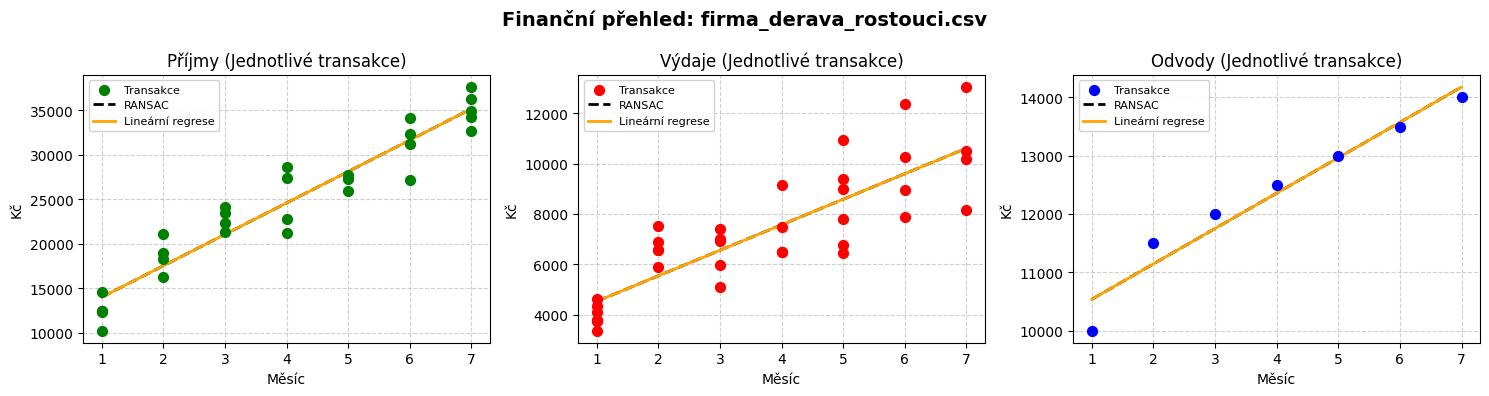

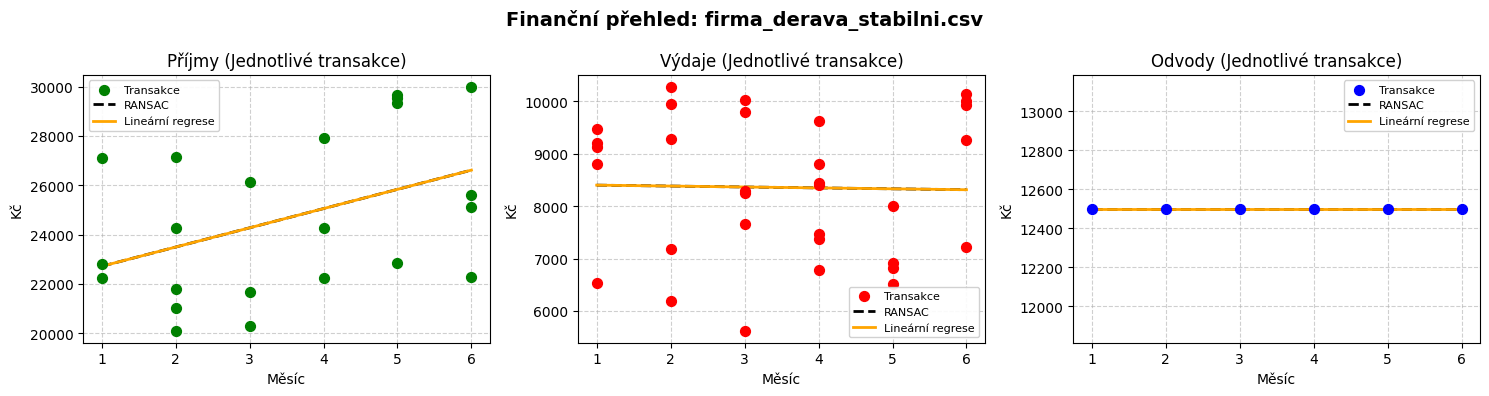

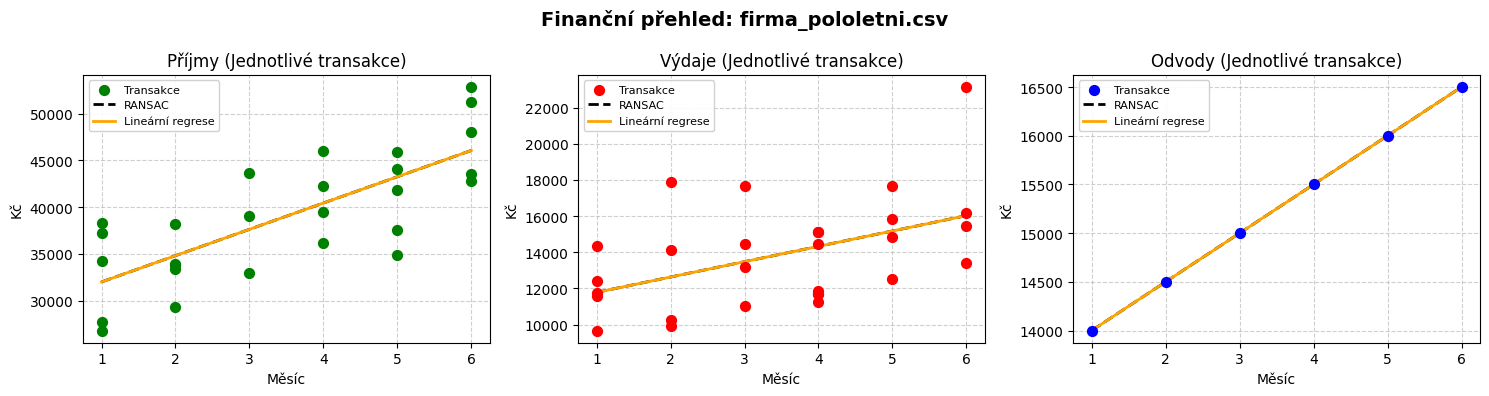

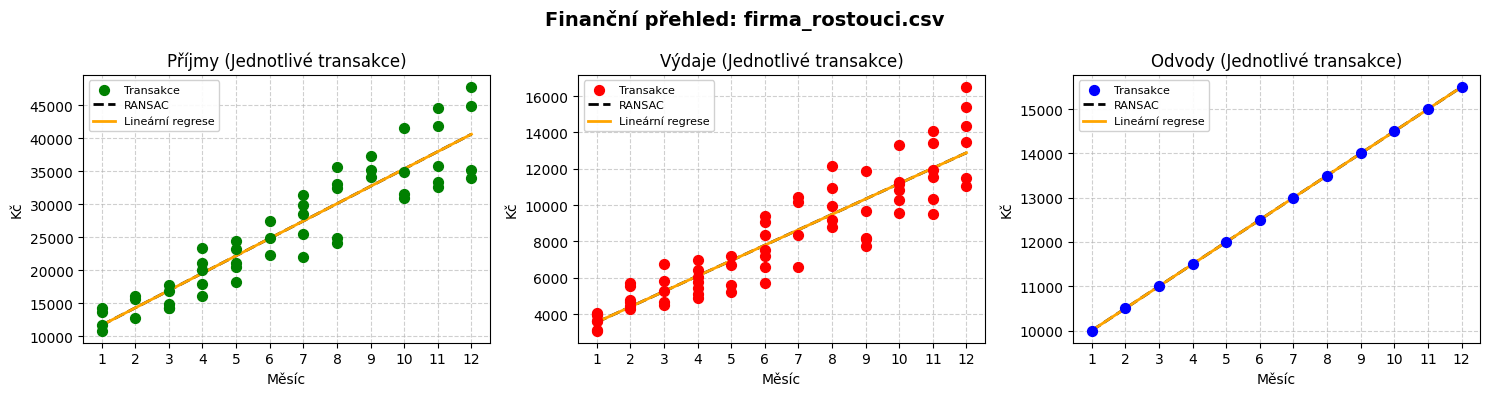

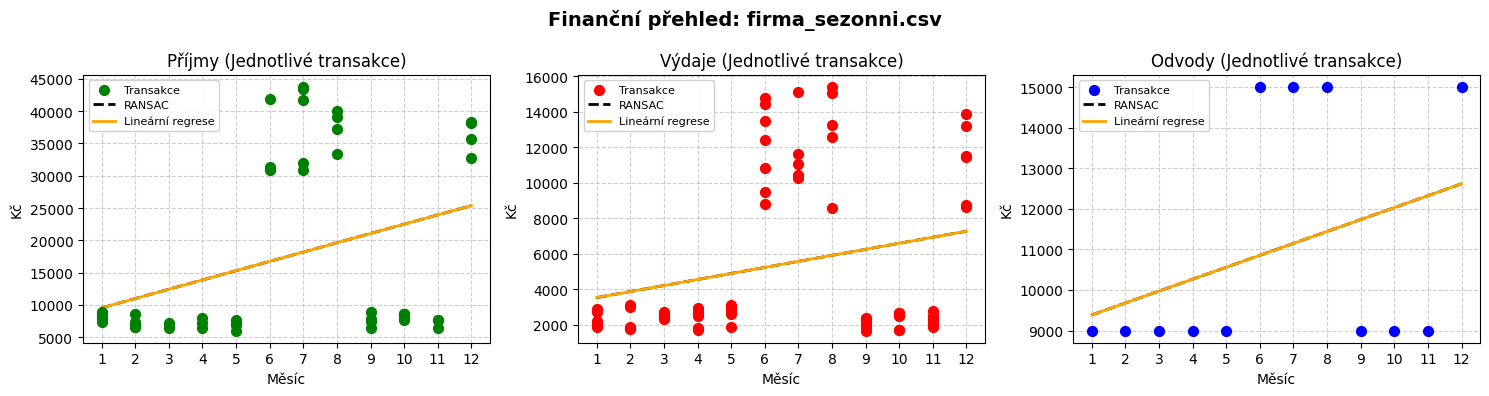

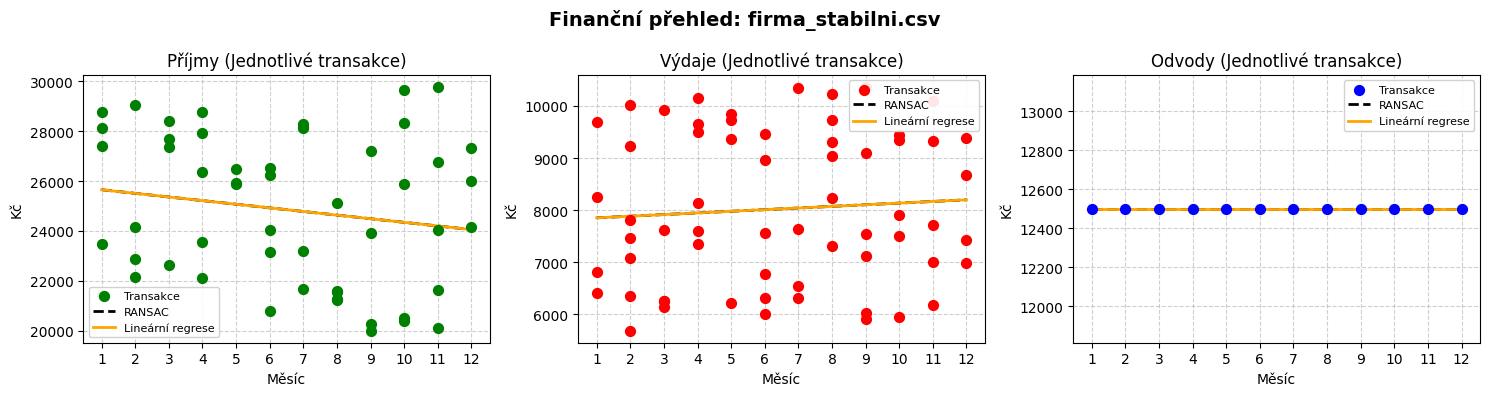

In [ ]:
from funkce import ransac_robust

model = ransac_robust.Ransac(prah=5000)

for data_firmy in vsechna_data:
    nazev = data_firmy["nazev"]
    
    x_prijmy, y_prijmy = [], []
    for index_mesice, transakce_v_mesici in enumerate(data_firmy["prijmy"].values(), start=1):
        for castka in transakce_v_mesici:
            x_prijmy.append(index_mesice)
            y_prijmy.append(castka)
            
    x_vydaje, y_vydaje = [], []
    for index_mesice, transakce_v_mesici in enumerate(data_firmy["vydaje"].values(), start=1):
        for castka in transakce_v_mesici:
            x_vydaje.append(index_mesice)
            y_vydaje.append(castka)
            
    x_odvody, y_odvody = [], []
    for index_mesice, transakce_v_mesici in enumerate(data_firmy["odvody"].values(), start=1):
        for castka in transakce_v_mesici:
            x_odvody.append(index_mesice)
            y_odvody.append(castka)

    # RANSAC fit
    fit_prijmy = model.fituj(x_prijmy, y_prijmy)
    fit_vydaje = model.fituj(x_vydaje, y_vydaje)
    fit_odvody = model.fituj(x_odvody, y_odvody)

    # Lineární regrese přes sklearn
    def lin_reg(x, y):
        lr = LinearRegression()
        lr.fit(np.array(x).reshape(-1, 1), y)
        x_u = np.sort(np.unique(x))
        return x_u, lr.predict(x_u.reshape(-1, 1))

    lr_prijmy_x, lr_prijmy_y = lin_reg(x_prijmy, y_prijmy)
    lr_vydaje_x, lr_vydaje_y = lin_reg(x_vydaje, y_vydaje)
    lr_odvody_x, lr_odvody_y = lin_reg(x_odvody, y_odvody)

    pocet_mesicu = len(data_firmy["prijmy"])
    osa_x_ticks  = np.arange(1, pocet_mesicu + 1)
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

    for ax, x, y, fit, lr_x, lr_y, barva, titulek in [
        (ax1, x_prijmy, y_prijmy, fit_prijmy, lr_prijmy_x, lr_prijmy_y, 'green',  'Příjmy'),
        (ax2, x_vydaje, y_vydaje, fit_vydaje, lr_vydaje_x, lr_vydaje_y, 'red',    'Výdaje'),
        (ax3, x_odvody, y_odvody, fit_odvody, lr_odvody_x, lr_odvody_y, 'blue',   'Odvody'),
    ]:
        ax.scatter(x, y, color=barva, s=50, zorder=3, label='Transakce')
        ax.plot(fit["x_unique"], fit["predikce"], color='black',  linestyle='--', linewidth=2, label='RANSAC')
        ax.plot(lr_x,            lr_y,            color='orange', linestyle='-',  linewidth=2, label='Lineární regrese')
        ax.set_title(f'{titulek} (Jednotlivé transakce)')
        ax.set_xlabel('Měsíc')
        ax.set_ylabel('Kč')
        ax.set_xticks(osa_x_ticks)
        ax.grid(True, linestyle='--', alpha=0.6, zorder=0)
        ax.legend(loc='best', fontsize=8, framealpha=0.9)

    fig.suptitle(f'Finanční přehled: {nazev}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()